# ME 3300 Lab 08 — Solution Notebook
**Thermocouples and First-Order Dynamic Response**

Instructor solution. Acquisition cells (dwfpy) are guarded by
`ADS_CONNECTED = False` so the notebook runs end-to-end against the synthetic
TA dataset in `../Data/` (from `generate_synthetic_data.py`). Set the flag
True at the bench to exercise the hardware path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import date

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

ADS_CONNECTED = False  # True only at the bench with hardware attached
today = date.today().strftime('%b %d, %Y')

## Part-3 — calibration captures (hardware path)

Two 10-second averaged captures: bead in room air, bead in the near-boiling
bath — each paired with a liquid-in-glass thermometer (LIGT) reading typed
into the logbook.

In [2]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    fs, duration = 50, 10.0
    n = int(fs * duration)

    with dwf.Device() as device:
        supplies = device.analog_io              # ±12 V for the follower
        supplies['V+']['Voltage'].value = 12.0
        supplies['V+']['Enable'].value  = True
        supplies['V-']['Voltage'].value = -12.0
        supplies['V-']['Enable'].value  = True
        supplies.master_enable = True            # (AD8495 runs off the 5 V switch)
        time.sleep(0.5)

        scope = device.analog_input
        scope['ch1'].setup(range=5.0)

        for name in ['Cal_RoomAir', 'Cal_Boiling']:
            input(f"{name}: bead in position, LIGT read and logged? Enter...")
            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            volts  = scope['ch1'].get_data()
            time_s = np.arange(n) / fs
            np.savetxt(f'../Data/{name}.csv',
                       np.column_stack([time_s, volts]),
                       header='Time (s),Channel 1 (V)', delimiter=',')
            print(f"  {name}: mean = {volts.mean():.4f} V")

## Part-3 — the two-point calibration

In [3]:
# LIGT readings (typed from the logbook)
T_air  = 21.4      # C — room air
T_boil = 97.4      # C — near-boiling bath (elevation-corrected!)

v_air  = np.loadtxt('../Data/Cal_RoomAir.csv', delimiter=',', comments='#')[:, 1].mean()
v_boil = np.loadtxt('../Data/Cal_Boiling.csv', delimiter=',', comments='#')[:, 1].mean()

# Two points define the line exactly: T = a1*V + a0
a1 = (T_boil - T_air) / (v_boil - v_air)     # sensitivity (C/V)
a0 = T_air - a1 * v_air                      # offset (C)

print(f"v_air = {v_air:.4f} V, v_boil = {v_boil:.4f} V")
print(f"calibration: T = {a1:.2f} * V + ({a0:.2f})")
print(f"datasheet ideal: T = 200.00 * V + (-250.00)   [T = (V - 1.25)/0.005]")

v_air = 1.3613 V, v_boil = 1.7413 V
calibration: T = 199.97 * V + (-250.82)
datasheet ideal: T = 200.00 * V + (-250.00)   [T = (V - 1.25)/0.005]


## Part-4 — three plunge captures with a cool-down gate (hardware path)

In [4]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    fs, duration = 1000, 5.0        # fast! tau is only ~50 ms
    n = int(fs * duration)

    with dwf.Device() as device:
        supplies = device.analog_io
        supplies['V+']['Voltage'].value = 12.0
        supplies['V+']['Enable'].value  = True
        supplies['V-']['Voltage'].value = -12.0
        supplies['V-']['Enable'].value  = True
        supplies.master_enable = True
        time.sleep(0.5)

        scope = device.analog_input
        scope['ch1'].setup(range=5.0)

        for run in [1, 2, 3]:
            # cool-down gate: wait until the bead is back near room temp
            while True:
                scope.single(sample_rate=100, buffer_size=100,
                             configure=True, start=True)
                T_now = a1 * scope['ch1'].get_data().mean() + a0
                if T_now < T_air + 3.0:
                    break
                print(f"  bead still at {T_now:.1f} C — keep cooling...")
                time.sleep(5)

            input(f"Run {run}: bead in air beside the bath. Press Enter, "
                  "then IMMEDIATELY plunge (capture runs 5 s)...")
            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            volts  = scope['ch1'].get_data()
            time_s = np.arange(n) / fs

            np.savetxt(f'../Data/Plunge_{run:02d}.csv',
                       np.column_stack([time_s, volts]),
                       header='Time (s),Channel 1 (V)', delimiter=',')
            print(f"  saved Plunge_{run:02d}.csv "
                  f"(end T = {a1*volts[-500:].mean()+a0:.1f} C)")

## Part-5 — step detection, time-shift, and the 63.2% method

In [5]:
def analyze_run(fname):
    """Load a plunge capture; return shifted (t, T), T0, Tss, tau63."""
    d = np.loadtxt(fname, delimiter=',', comments='#')
    T_full = a1 * d[:, 1] + a0               # volts -> C via YOUR calibration
    t_full = d[:, 0]

    T0 = T_full[:1000].mean()                # early window: pre-plunge, pre-steam

    # Detect the plunge: a >5 C rise across 10 samples (10 ms) can only be
    # the step — noise (~0.2 C) and steam preheat (~1.5 C, slow) can't do it.
    rise10 = T_full[10:] - T_full[:-10]
    idx = np.argmax(rise10 > 5.0)
    idx += np.argmax(T_full[idx:idx + 10] > T0 + 1.0)   # refine: the takeoff

    t = t_full[idx:] - t_full[idx]           # t = 0 at the plunge
    T = T_full[idx:]

    Tss = T[-1000:].mean()                   # settled end of record
    T63 = T0 + 0.632 * (Tss - T0)            # Eq. 4
    tau63 = t[np.argmax(T >= T63)]

    return t, T, T0, Tss, tau63


runs = [analyze_run(f'../Data/Plunge_{i:02d}.csv') for i in [1, 2, 3]]

taus = np.array([r[4] for r in runs])
print("run | T0 (C) | Tss (C) | tau63 (ms)")
for i, (t, T, T0, Tss, tau63) in enumerate(runs, start=1):
    print(f"  {i} | {T0:6.1f} | {Tss:6.1f}  |  {tau63*1000:6.1f}")
print(f"\nmean tau63 = {taus.mean()*1000:.1f} ms")

run | T0 (C) | Tss (C) | tau63 (ms)
  1 |   22.8 |   97.4  |    44.0
  2 |   21.9 |   97.4  |    47.0
  3 |   23.1 |   97.4  |    44.0

mean tau63 = 45.0 ms


## Part-5 — the three-run step-response figure

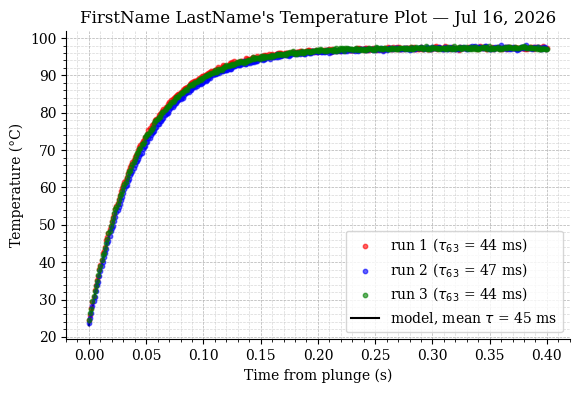

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

colors = ['red', 'blue', 'green']
for i, ((t, T, T0, Tss, tau63), color) in enumerate(zip(runs, colors), start=1):
    show = (t > -0.1) & (t < 0.4)            # focus on the transient
    ax.scatter(t[show], T[show], s=10, color=color, alpha=0.6,
               label=f'run {i} ($\\tau_{{63}}$ = {tau63*1000:.0f} ms)', zorder=3)

# first-order model at the mean tau, from the last run's levels
t_model = np.linspace(0, 0.4, 300)
T_model = Tss + (T0 - Tss) * np.exp(-t_model / taus.mean())
ax.plot(t_model, T_model, 'k-', linewidth=1.5,
        label=f'model, mean $\\tau$ = {taus.mean()*1000:.0f} ms')

ax.set_xlabel('Time from plunge (s)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f"FirstName LastName's Temperature Plot — {today}")
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right')

fig.savefig('../Figures/FirstName_LastName_Lab08_StepResponse.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab08_StepResponse.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-6 — the error-fraction method (best run)

Tss comes from the LIGT (the trusted reference), not from the data tail.
The log-transform turns the exponential into a line; the slope's CI
propagates into tau's CI by the derivative rule (Lab 06).

In [7]:
t, T, T0, Tss_data, tau63 = runs[0]          # best run

Tss = T_boil                                  # LIGT value — the reference

Gamma = (Tss - T) / (Tss - T0)                # error fraction (Eq. 5)
valid = (Gamma > 0.02) & (Gamma < 0.95)       # the exponential range only
t_v      = t[valid]
ln_Gamma = np.log(Gamma[valid])

coeffs = np.polyfit(t_v, ln_Gamma, 1)         # ln(Gamma) = -t/tau
slope  = coeffs[0]
tau_ef = -1.0 / slope

N      = np.count_nonzero(valid)
nu     = N - 2
resid  = ln_Gamma - np.polyval(coeffs, t_v)
s_yx   = np.sqrt(np.sum(resid**2)) / np.sqrt(nu)
S_m    = s_yx / np.sqrt(np.sum((t_v - t_v.mean())**2))
CI_m   = stats.t.ppf(0.975, df=nu) * S_m

# propagate slope CI into tau (tau = -1/slope -> u_tau/tau = u_slope/|slope|)
CI_tau = tau_ef * CI_m / abs(slope)

print(f"slope = {slope:.3f} ± {CI_m:.3f} 1/s (95% CI), N = {N}")
print(f"tau (error fraction) = {tau_ef*1000:.1f} ± {CI_tau*1000:.1f} ms")
print(f"tau (63.2%, same run) = {tau63*1000:.1f} ms")

slope = -22.653 ± 0.162 1/s (95% CI), N = 167
tau (error fraction) = 44.1 ± 0.3 ms
tau (63.2%, same run) = 44.0 ms


## Part-6 — the error-fraction figure

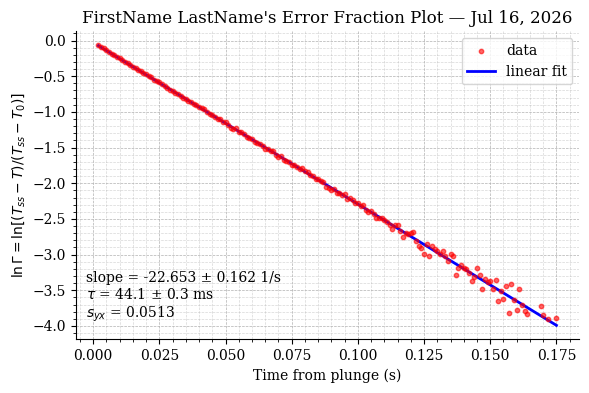

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

ax.scatter(t_v, ln_Gamma, s=10, color='red', alpha=0.6, label='data', zorder=3)
ax.plot(t_v, np.polyval(coeffs, t_v), 'b-', linewidth=2, label='linear fit')

ax.set_xlabel('Time from plunge (s)')
ax.set_ylabel(r'$\ln \Gamma = \ln[(T_{ss} - T)/(T_{ss} - T_0)]$')
ax.set_title(f"FirstName LastName's Error Fraction Plot — {today}")
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')

ax.text(0.02, 0.05,
        f'slope = {slope:.3f} ± {CI_m:.3f} 1/s\n'
        f'$\\tau$ = {tau_ef*1000:.1f} ± {CI_tau*1000:.1f} ms\n'
        f'$s_{{yx}}$ = {s_yx:.4f}',
        transform=ax.transAxes, ha='left', va='bottom')

fig.savefig('../Figures/FirstName_LastName_Lab08_ErrorFraction.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab08_ErrorFraction.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Grading / checking notes (TA)

**Calibration (Part-3).** Sensitivity a1 should land within a few % of the
datasheet's 200 C/V; the offset a0 typically differs from −250 C by
~0.5–1.5 C — that's the LM358 follower's input offset, calibrated out.
Students who *notice* the a0 discrepancy and name the buffer are gold.
a1 far from 200 → wrong LIGT units (F vs C) or wires swapped.

**Step captures (Part-4).** tau ~ 30–70 ms is physical for a bare bead in
stirred near-boiling water. tau ~ 300+ ms → bead touched the beaker wall or
wasn't submerged. A pre-step hump of a degree or two (run 2 of the
synthetic set) is the steam preheat — the manual's common-mistakes list;
the 10-sample rise detector correctly ignores it, and it's a good viva
question ("why didn't your detector fire on the hump?").

**63.2% vs error fraction.** The two methods should agree within ~10%.
Systematic disagreements: (a) Tss taken from the data tail instead of the
LIGT biases Gamma near the end — the mask (Gamma > 0.02) limits the damage;
(b) t=0 detected late biases tau63 low (detector bias here is < ~1 ms);
(c) including post-settle noise in the fit (no mask) wrecks the slope —
same lesson as Lab 05's saturation mask.

**Linearity.** ln(Gamma) should be straight over the masked range; visible
curvature at early times is the steam/entry transition, at late times the
Tss mismatch. Students citing straightness as *evidence the sensor is
first-order* have the right idea.

**Sample rate question.** With tau ~ 45 ms, 1000 Hz gives ~45 samples per
tau — comfortable. Students proposing 10–50 Hz for a repeat should be
pushed on it (5–2 samples per tau; the Lab 04 lesson).